In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict, StratifiedGroupKFold

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import CondensedNearestNeighbour, RandomUnderSampler, TomekLinks, NearMiss, EditedNearestNeighbours
from imblearn.combine import SMOTETomek
from sklearn.decomposition import PCA
from sklearn.calibration import calibration_curve, CalibratedClassifierCV


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import average_precision_score, precision_recall_curve, auc, confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score
import shap

In [2]:
# Load Dataset
raw_df = pd.read_csv('../data/f5_data/f5_final.csv')
raw_df

,transcript_id,transcript_position,gene_id,label,log_mean_0,log_mean_1,log_mean_2,log_std_0,log_std_1,log_std_2,...,all_dwell,log_mean_0_iqr,log_mean_1_iqr,log_mean_2_iqr,log_std_0_iqr,log_std_1_iqr,log_std_2_iqr,dwell_0_iqr,log_dwell_1_iqr,log_dwell_2_iqr
0,ENST00000000233,244,ENSG00000004059,0,-4.966140,-4.832071,-5.119335,1.316408,1.894617,1.235471,...,110.500000,-5.008637,-4.933674,-5.119335,0.463734,1.710188,1.316408,3.0,1.386294,1.098612
1,ENST00000000233,261,ENSG00000004059,0,-5.177871,-5.135349,-4.992304,1.057790,1.098612,0.978326,...,104.033333,-5.613028,-5.521461,-5.288862,0.262364,0.173953,0.279524,4.0,1.386294,1.073294
2,ENST00000000233,316,ENSG00000004059,0,-5.065620,-5.065620,-5.065620,0.974560,1.329724,0.647103,...,98.233333,-5.253344,-5.236282,-5.414851,0.190620,0.029559,-0.105361,1.0,1.131402,0.530628
3,ENST00000000233,332,ENSG00000004059,0,-4.708311,-4.917145,-5.302325,1.745716,0.968883,0.758467,...,105.800000,-4.972617,-5.178758,-5.612343,1.208960,-0.030459,-0.251672,3.0,0.832909,1.446919
4,ENST00000000233,368,ENSG00000004059,0,-4.714985,-4.556380,-4.745007,1.874874,1.733424,1.425515,...,108.466667,-4.812194,-5.004156,-5.105633,0.515813,0.763140,0.462160,3.0,0.693147,1.186318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,ENSG00000167747,1,-4.807286,-5.238163,-5.370888,1.163151,1.521699,1.291984,...,105.366667,-5.158555,-5.119335,-5.511511,0.239017,0.841567,0.438255,2.0,1.609438,1.410987
121834,ENST00000641834,1429,ENSG00000167747,0,-5.086437,-4.645992,-5.334981,1.305626,2.212660,1.235471,...,102.866667,-5.124364,-4.778334,-5.722965,0.698135,1.235471,0.182322,3.0,1.386294,1.098612
121835,ENST00000641834,1531,ENSG00000167747,1,-4.966140,-5.162913,-5.151623,1.342865,1.490654,0.654926,...,104.166667,-5.394828,-5.388789,-5.800844,0.563892,0.805359,-0.307885,2.0,0.810930,0.680568
121836,ENST00000641834,1537,ENSG00000167747,0,-5.020686,-4.989363,-5.065620,1.150572,1.756132,0.845868,...,105.333333,-5.276556,-5.567505,-5.779584,-0.051293,1.205971,0.122218,4.0,1.386294,1.193922


### 1. Train Test Split
* Stratify by gene_id and label

In [3]:
# Step 1: create the combined column
raw_df['combined'] = raw_df['gene_id'].astype(str) + '_' + raw_df['label'].astype(str)

# Step 2: count occurrences of the combined column
counts = raw_df['combined'].value_counts()

# Step 3: where count == 1, replace with just column2
raw_df['final_group'] = raw_df.apply(
    lambda row: row['label'] if counts[row['combined']] == 1 else row['combined'],
    axis=1
)
raw_df['final_group'] = raw_df['final_group'].astype(str)

# Split into X and y
X = raw_df.drop(columns=['gene_id', 'combined'])
y = raw_df['label']

# Split into 95% vs 5%
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=raw_df['final_group'], test_size=0.05, random_state=42)
X_test_id = X_test[['transcript_position', 'transcript_id']]
X_train.drop(columns=['transcript_position', 'transcript_id', 'label', 'final_group'], inplace=True)
X_test.drop(columns=['transcript_position', 'transcript_id', 'label', 'final_group'], inplace=True)


display(X_train)
display(X_test)

# Split by gene_id in each CV fold
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


,log_mean_0,log_mean_1,log_mean_2,log_std_0,log_std_1,log_std_2,dwell_0,dwell_1,dwell_2,seq_5mer_0_AAAAC,...,all_dwell,log_mean_0_iqr,log_mean_1_iqr,log_mean_2_iqr,log_std_0_iqr,log_std_1_iqr,log_std_2_iqr,dwell_0_iqr,log_dwell_1_iqr,log_dwell_2_iqr
96385,-4.954019,-5.092931,-5.143881,0.968883,1.302913,0.737164,106.0,102.00,86.65,0.0,...,98.216667,-5.269244,-5.370888,-5.469106,-0.360253,0.039221,-0.251672,2.50,1.294727,1.252763
3936,-5.054587,-5.177871,-4.887533,0.989541,1.673351,0.783902,117.0,116.00,85.70,0.0,...,106.233333,-5.128575,-4.807286,-5.613028,0.296394,1.228177,0.292670,2.50,1.386294,0.587787
10035,-4.977684,-5.302325,-5.107697,0.741937,0.966984,0.770108,106.0,104.00,89.50,0.0,...,99.833333,-5.268759,-5.585999,-5.264883,0.553885,-0.139262,-0.248461,4.00,1.609438,1.029619
31397,-5.030583,-4.709975,-5.088867,1.531476,1.576915,1.359694,123.0,127.00,82.10,0.0,...,110.700000,-5.285401,-4.974786,-5.512749,1.381282,0.749055,1.516774,4.25,1.098612,1.259880
59792,-5.238163,-4.942743,-4.954019,1.214913,2.255493,1.011601,103.5,116.00,84.35,0.0,...,101.283333,-5.843907,-4.730167,-5.235812,0.067659,1.148988,0.407130,4.75,1.749200,1.073294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95754,-4.791500,-5.238163,-5.119335,0.924259,1.026042,0.631272,107.0,102.00,89.60,1.0,...,99.533333,-4.474581,-5.306350,-5.191258,-0.210721,0.044017,0.044017,2.00,1.492904,1.064711
3416,-5.234404,-4.873050,-5.370888,0.438255,0.553885,0.688135,93.2,94.70,88.20,0.0,...,92.033333,-5.423881,-5.032881,-5.347508,-0.287682,-0.967584,-0.527633,5.60,0.336472,0.470004
56424,-4.792705,-4.832071,-5.238163,1.320422,2.102303,1.133014,119.0,119.00,81.00,0.0,...,106.333333,-4.949070,-4.906613,-5.444500,1.150572,1.254904,0.431782,3.00,1.791759,1.223775
38624,-4.648078,-5.232530,-5.189463,1.932970,1.424312,0.641854,131.0,95.55,85.80,0.0,...,104.116667,-4.724517,-5.590677,-5.990465,1.302913,0.350657,-0.371064,3.00,1.170933,0.500775


,log_mean_0,log_mean_1,log_mean_2,log_std_0,log_std_1,log_std_2,dwell_0,dwell_1,dwell_2,seq_5mer_0_AAAAC,...,all_dwell,log_mean_0_iqr,log_mean_1_iqr,log_mean_2_iqr,log_std_0_iqr,log_std_1_iqr,log_std_2_iqr,dwell_0_iqr,log_dwell_1_iqr,log_dwell_2_iqr
57478,-5.014643,-5.238163,-5.351718,0.985817,1.229641,0.924259,107.0,97.6,89.10,0.0,...,97.900000,-5.621281,-5.695814,-5.399243,0.086178,0.657520,0.350657,3.00,1.504077,1.064711
112254,-4.840893,-5.012387,-5.364457,1.624327,1.133014,0.934131,130.0,98.9,90.95,0.0,...,106.616667,-5.346983,-6.080296,-5.497989,0.860778,-0.186330,0.505310,4.50,0.777029,2.240710
88843,-5.117664,-5.015397,-5.177871,1.002468,1.633154,1.364815,121.0,125.0,88.40,0.0,...,111.466667,-5.229258,-5.174331,-5.523964,0.093035,1.334343,0.420354,10.00,0.693147,1.341558
5175,-5.199377,-5.041352,-5.177871,2.144761,1.096944,0.744315,117.0,101.0,93.50,0.0,...,103.833333,-5.383331,-5.238163,-5.238634,0.916291,0.169743,-0.321584,5.00,1.147402,1.020651
93101,-5.177871,-4.877635,-5.065620,1.287854,1.825355,1.498506,122.0,127.5,80.70,0.0,...,110.066667,-5.161604,-5.301322,-5.284414,0.113329,1.453369,1.421299,3.75,1.386294,1.073294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93652,-5.148175,-5.031348,-5.014643,0.565314,0.845868,0.717840,93.4,98.7,91.40,0.0,...,94.500000,-5.261985,-5.400350,-5.786078,-0.423120,-0.192372,-0.446287,1.85,0.615186,0.896088
38718,-4.966140,-5.302325,-5.232530,2.122262,1.481605,0.920283,119.0,92.1,81.10,0.0,...,97.400000,-5.322610,-5.518964,-5.707790,1.265538,0.494696,-0.099820,6.00,1.578979,1.321756
67598,-5.207563,-4.871091,-5.299318,0.850151,1.049072,0.725130,108.0,108.0,94.70,0.0,...,103.566667,-5.353830,-5.265850,-5.780394,0.348895,-0.325038,-0.458075,3.00,0.693147,1.216395
26564,-5.107697,-5.065620,-5.188567,2.081938,1.348073,0.732368,126.0,94.4,85.90,0.0,...,102.100000,-4.949070,-5.318520,-5.528989,1.497388,0.086178,-0.307885,8.00,1.098612,0.693147


### 2. Check Over-sampling/Under-sampling Techniques

PCA Plot

In [4]:
# sm = SMOTE(random_state=42)
# X_res, y_res = sm.fit_resample(X_train, y_train)

# # Standard Scaler for PCA
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_train)
# X_res_scaled = scaler.fit_transform(X_res)

# # PCA
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)
# X_res_pca = pca.transform(X_res_scaled)

# # Plot PCA
# fig, ax = plt.subplots(1, 2, figsize=(12,5))
# sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_train, ax=ax[0], alpha=0.7)
# ax[0].set_title("Before SMOTE")

# sns.scatterplot(x=X_res_pca[:,0], y=X_res_pca[:,1], hue=y_res, ax=ax[1], alpha=0.7)
# ax[1].set_title("After SMOTE")
# plt.show()

t-SNE Plot

In [5]:
# X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_train)

# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='coolwarm', alpha=0.6)
# plt.title("t-SNE projection")
# plt.show()

UMAP Plot

In [6]:
# reducer = umap.UMAP(random_state=42)
# scaled_umap = StandardScaler().fit_transform(X_train)
# X_umap_before = reducer.fit_transform(scaled_umap)

# plt.scatter(X_umap_before[:,0], X_umap_before[:,1], c=y_train, cmap='coolwarm', alpha=0.5)
# plt.title("UMAP Before SMOTETomek")
# plt.show()

# # X_umap_after = reducer.fit_transform(X_res)
# # plt.scatter(X_umap_after[:,0], X_umap_after[:,1], c=y_res, cmap='coolwarm', alpha=0.5)
# # plt.title("UMAP After SMOTETomek")
# # plt.show()

### 3. Baseline Model: Logistic Regression

In [7]:
pipe = Pipeline(steps = [
    # ('cnn', CondensedNearestNeighbour(random_state=42)),
    # ('smote', SMOTE(random_state=42, sampling_strategy=0.2)),
    # ('rus', RandomUnderSampler(random_state=42)),
    # ('smotetomek', SMOTETomek(random_state=42)),
    # ('tl', TomekLinks()),
    # ('nm', NearMiss(version=1)),
    # ('enn', EditedNearestNeighbours()),
    # ('robustscaler', RobustScaler()),
    ('standardscaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, class_weight='balanced', max_iter=10000))
])

train_cv = cross_val_score(pipe, X_train, y_train, cv=cv, verbose=2, scoring='average_precision')
train_cv_mean = np.mean(train_cv)
print(f'10-Fold Cross Validation Score on training data: {train_cv_mean}')

pipe.fit(X_train, y_train)

[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.9s
10-Fold Cross Validation Score on training data: 0.4377789041868899


,steps,"[('standardscaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


Performance of Untuned Model on test set

In [8]:
# Average Precision
y_pred_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = pipe.predict(X_test)


precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"PR AUC: {pr_auc}")

PR AUC: 0.25022840925696127


### 4. Random Forest

In [9]:
rf_pipe = Pipeline(steps = [
    # ('cnn', CondensedNearestNeighbour(random_state=42)),
    # ('smote', SMOTE(random_state=42, sampling_strategy=0.2)),
    # ('rus', RandomUnderSampler(random_state=42)),
    # ('smotetomek', SMOTETomek(random_state=42)),
    # ('tl', TomekLinks()),
    # ('nm', NearMiss(version=1)),
    # ('enn', EditedNearestNeighbours()),
    # ('robustscaler', RobustScaler()),
    # ('standardscaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])


train_cv_rf = cross_val_score(rf_pipe, X_train, y_train, cv=cv, verbose=3, scoring='average_precision')
train_cv_rf_mean = np.mean(train_cv_rf)

print(f'10-Fold Cross Validation Score on training data: {train_cv_rf_mean}')
rf_pipe.fit(X_train, y_train)

[CV] END ................................ score: (test=0.473) total time=  32.5s
[CV] END ................................ score: (test=0.492) total time=  34.7s
[CV] END ................................ score: (test=0.490) total time=  33.5s
[CV] END ................................ score: (test=0.492) total time=  32.8s
[CV] END ................................ score: (test=0.508) total time=  33.1s
[CV] END ................................ score: (test=0.520) total time=  35.1s
[CV] END ................................ score: (test=0.472) total time=  33.8s
[CV] END ................................ score: (test=0.490) total time=  38.4s
[CV] END ................................ score: (test=0.514) total time=  39.9s
[CV] END ................................ score: (test=0.492) total time=  40.1s
10-Fold Cross Validation Score on training data: 0.4941156386500011


,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'


Performance of Untuned Model on test set

In [10]:
# Get Predictions
y_pred_prob = rf_pipe.predict_proba(X_test)[:, 1]
y_pred = rf_pipe.predict(X_test)

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"PR AUC: {pr_auc}")

ap_score = average_precision_score(y_test, y_pred_prob)
print(f'Average Precision: {ap_score}')

PR AUC: 0.3500711734803114
Average Precision: 0.3448806377876916


### 4b. Check Feature Importance

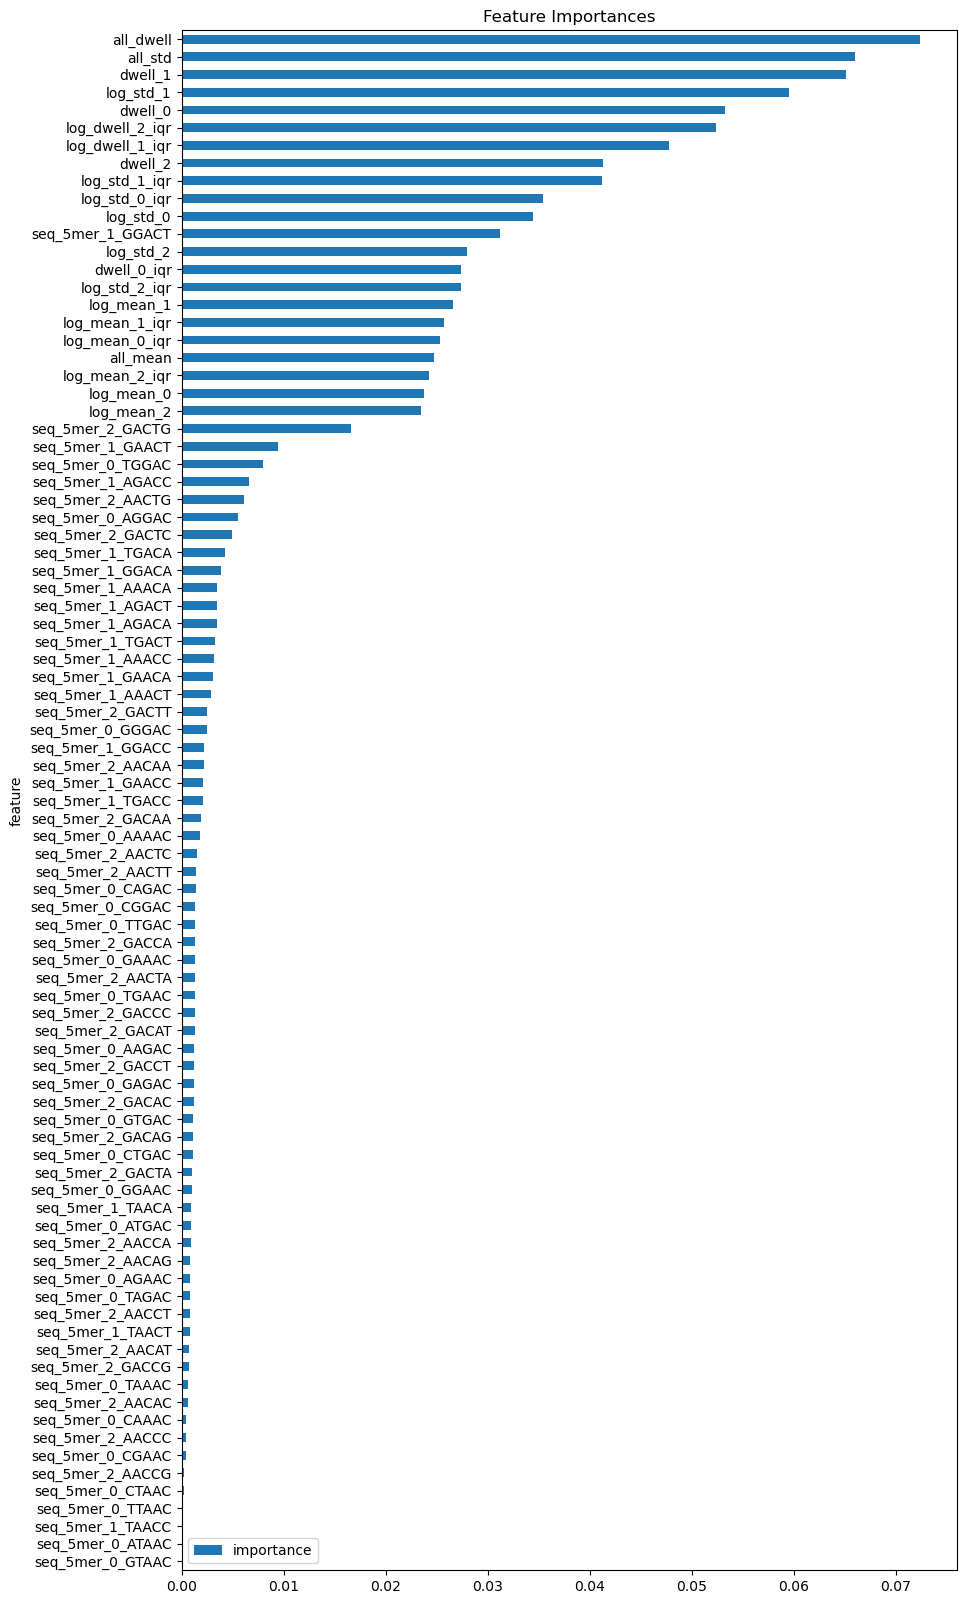

In [11]:
rf_model = rf_pipe.named_steps['model']

# Feature importance values
importances = rf_model.feature_importances_

# Match with your original feature names
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)


feat_imp_df.plot(
    x='feature', y='importance', kind='barh', figsize=(10, 20)
)
plt.gca().invert_yaxis()
plt.title("Feature Importances")

plt.show()

#### 4c. Check Calibration Curve

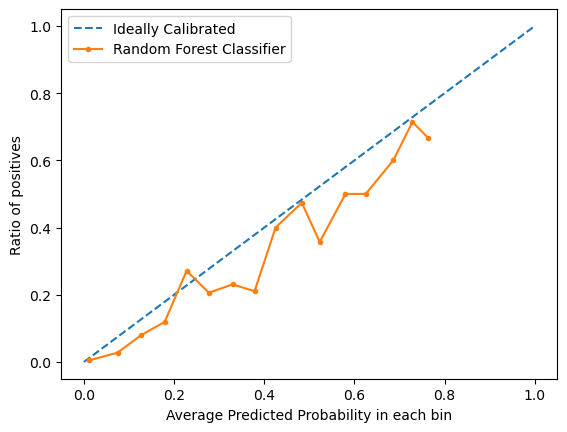

In [12]:
x, y = calibration_curve(y_test, y_pred_prob, n_bins=20)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')

# Plot model's calibration curve
plt.plot(y, x, marker = '.', label = 'Random Forest Classifier')

leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.show()

In [14]:
# Calibrate Model on Test Data
calibrator = CalibratedClassifierCV(rf_pipe, cv='prefit', method='isotonic')
calibrator.fit(X_train, y_train)

y_pred_cal = calibrator.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_cal)
pr_auc = auc(recall, precision)
print(f"PR AUC: {pr_auc}")

ap_score = average_precision_score(y_test, y_pred_cal)
print(f'Average Precision: {ap_score}')

c:\Users\janeh\anaconda3\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


PR AUC: 0.3853149847883117
Average Precision: 0.1903887280000567


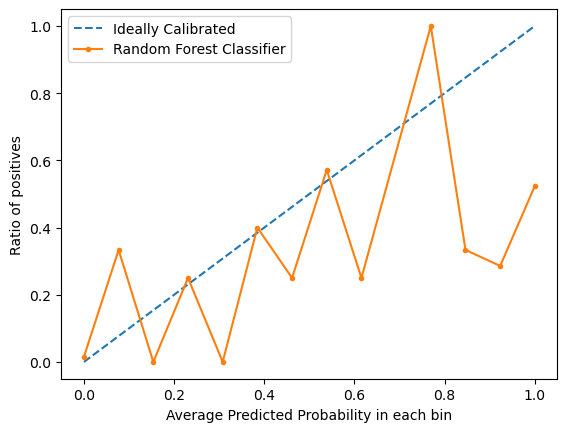

In [15]:
x, y = calibration_curve(y_test, y_pred_cal, n_bins=20)

plt.plot([0, 1], [0, 1], linestyle = '--', label = 'Ideally Calibrated')

# Plot model's calibration curve
plt.plot(y, x, marker = '.', label = 'Random Forest Classifier')

leg = plt.legend(loc = 'upper left')
plt.xlabel('Average Predicted Probability in each bin')
plt.ylabel('Ratio of positives')
plt.show()

#### 4d. Train Balanced Random Forest

In [16]:
balanced_rf = BalancedRandomForestClassifier(random_state=42, class_weight='balanced')
train_cv_brf = cross_val_score(balanced_rf, X_train, y_train, scoring='average_precision', verbose=3)
print(np.mean(train_cv_brf))

balanced_rf.fit(X_train, y_train)

[CV] END ................................ score: (test=0.417) total time=  11.5s
[CV] END ................................ score: (test=0.433) total time=  11.6s
[CV] END ................................ score: (test=0.412) total time=  11.0s
[CV] END ................................ score: (test=0.445) total time=  10.8s
[CV] END ................................ score: (test=0.463) total time=  12.0s
0.4338920343713143


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [17]:
y_pred_brf = balanced_rf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_brf)
pr_auc = auc(recall, precision)
print(f"PR AUC: {pr_auc}")

ap_score = average_precision_score(y_test, y_pred_brf)
print(f'Average Precision: {ap_score}')

temp_df = pd.DataFrame({
    'y_test': y_test, 
    'y_pred_prob': y_pred_brf
})

PR AUC: 0.2845546822949384
Average Precision: 0.28059992297988684


### 5. XGBoost

In [18]:
xgb_pipe = Pipeline(steps=[
    ('standardscaler', StandardScaler()),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        random_state=42,
        scale_pos_weight=1  
    ))
])


train_cv_xgb = cross_val_score(xgb_pipe, X_train, y_train, cv=cv, verbose=2, scoring='average_precision')
train_cv_xgb_mean = np.mean(train_cv_xgb)
xgb_pipe.fit(X_train, y_train)

print(f'10-Fold Cross Validation Score on training data: {train_cv_xgb_mean}')

[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   1.1s
[CV] END .................................................... total time=   1.1s
10-Fold Cross Validation Score on training data: 0.4597349019351495


Performance of Untuned Model on Test Set

In [19]:
# Get Predictions
y_pred_prob = xgb_pipe.predict_proba(X_test)[:, 1]
y_pred = xgb_pipe.predict(X_test)

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"PR AUC: {pr_auc}")

PR AUC: 0.2595557129363604


### 6. LightGBM
* Removed One Hot Encoding for the 3 5-mer sequences > Kept them as categorical columns

In [20]:
gbm_df = pd.read_csv('../data/f5_data/f5_lightgbm.csv')

#### 6a. Train Test Split

In [21]:
# Step 1: create the combined column
gbm_df['combined'] = gbm_df['gene_id'].astype(str) + '_' + gbm_df['label'].astype(str)

# Step 2: count occurrences of the combined column
counts = gbm_df['combined'].value_counts()

# Step 3: where count == 1, replace with just column2
gbm_df['final_group'] = gbm_df.apply(
    lambda row: row['label'] if counts[row['combined']] == 1 else row['combined'],
    axis=1
)
gbm_df['final_group'] = gbm_df['final_group'].astype(str)

# Split into X and y
X = gbm_df.drop(columns=['gene_id', 'combined'])
y = gbm_df['label']

# Split into 95% vs 5%
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=gbm_df['final_group'], test_size=0.05, random_state=42)
X_train.drop(columns=['transcript_position', 'transcript_id', 'label', 'final_group'], inplace=True)
X_test.drop(columns=['transcript_position', 'transcript_id', 'label', 'final_group'], inplace=True)

display(X_train)
display(y_train)

,dwell_0,dwell_1,dwell_2,dwell_0_iqr,seq_5mer_0,seq_5mer_1,seq_5mer_2,log_mean_0,log_std_0,log_mean_1,...,log_std_0_iqr,log_mean_1_iqr,log_std_1_iqr,log_dwell_1_iqr,log_mean_2_iqr,log_std_2_iqr,log_dwell_2_iqr,all_mean,all_std,all_dwell
96385,106.0,102.00,86.65,2.50,CAAAC,AAACC,AACCC,-4.954019,0.968883,-5.092931,...,-0.360253,-5.370888,0.039221,1.294727,-5.469106,-0.251672,1.252763,0.006343,2.801667,98.216667
3936,117.0,116.00,85.70,2.50,TGGAC,GGACT,GACTT,-5.054587,0.989541,-5.177871,...,0.296394,-4.807286,1.228177,1.386294,-5.613028,0.292670,0.587787,0.006520,3.403333,106.233333
10035,106.0,104.00,89.50,4.00,GAAAC,AAACT,AACTG,-4.977684,0.741937,-5.302325,...,0.553885,-5.585999,-0.139262,1.609438,-5.264883,-0.248461,1.029619,0.005973,2.296667,99.833333
31397,123.0,127.00,82.10,4.25,GAGAC,AGACC,GACCG,-5.030583,1.531476,-4.709975,...,1.381282,-4.974786,0.749055,1.098612,-5.512749,1.516774,1.259880,0.007235,4.453333,110.700000
59792,103.5,116.00,84.35,4.75,GTGAC,TGACA,GACAT,-5.238163,1.214913,-4.942743,...,0.067659,-4.730167,1.148988,1.749200,-5.235812,0.407130,1.073294,0.006500,5.220000,101.283333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95754,107.0,102.00,89.60,2.00,AAAAC,AAACA,AACAG,-4.791500,0.924259,-5.238163,...,-0.210721,-5.306350,0.044017,1.492904,-5.191258,0.044017,1.064711,0.006530,2.396667,99.533333
3416,93.2,94.70,88.20,5.60,CTAAC,TAACA,AACAC,-5.234404,0.438255,-4.873050,...,-0.287682,-5.032881,-0.967584,0.336472,-5.347508,-0.527633,0.470004,0.005877,1.760000,92.033333
56424,119.0,119.00,81.00,3.00,TGGAC,GGACA,GACAA,-4.792705,1.320422,-4.832071,...,1.150572,-4.906613,1.254904,1.791759,-5.444500,0.431782,1.223775,0.007190,5.011667,106.333333
38624,131.0,95.55,85.80,3.00,AGAAC,GAACC,AACCT,-4.648078,1.932970,-5.232530,...,1.302913,-5.590677,0.350657,1.170933,-5.990465,-0.371064,0.500775,0.006832,4.321667,104.116667


96385    0
3936     0
10035    1
31397    0
59792    0
        ..
95754    0
3416     0
56424    0
38624    0
74251    0
Name: label, Length: 115746, dtype: int64

#### 6b. Train LightGBM

In [22]:
for col in ['seq_5mer_0', 'seq_5mer_1', 'seq_5mer_2']:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=['seq_5mer_0', 'seq_5mer_1', 'seq_5mer_2'])
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    "objective": "binary",
    "boosting_type": "gbdt",            
    "metric": ["auc", "average_precision"],
    "num_leaves": 31,                   
    "learning_rate": 0.05,             
    "feature_fraction": 0.8,           
    "bagging_fraction": 0.8,          
    "bagging_freq": 5,                  
    "scale_pos_weight":  (len(y_train) - sum(y_train)) / sum(y_train),  
    "min_data_in_leaf": 20,            
    "max_depth": -1,                    
    "lambda_l1": 1.0,                  
    "lambda_l2": 1.0,               
    "verbose": -1,
    "force_row_wise": True
}
# Train the LightGBM model
num_round = 500
bst = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    valid_names=["train", "test"],
)

print(bst.best_score)

defaultdict(<class 'collections.OrderedDict'>, {'train': OrderedDict({'auc': 0.9936914996236648, 'average_precision': 0.8305223794491757}), 'test': OrderedDict({'auc': 0.9157234062980031, 'average_precision': 0.2882410437944657})})


Performance of LightGBM on Test Set

In [23]:
# Make predictions
y_pred_prob = bst.predict(X_test)

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"PR AUC: {pr_auc}")

PR AUC: 0.28497133582328893


### 5. CatBoost

#### 5a. Prepare CatBoost Dataset

In [24]:
train_pool  = Pool(X_train, y_train, cat_features=['seq_5mer_0', 'seq_5mer_1', 'seq_5mer_2'])
eval_pool = Pool(X_test, y_test, cat_features=['seq_5mer_0', 'seq_5mer_1', 'seq_5mer_2'])

#### 5b. Train CatBoost

In [25]:
catboost = CatBoostClassifier(random_state=42, verbose=50, loss_function='Logloss')
catboost.fit(X_train, y_train, cat_features=['seq_5mer_0', 'seq_5mer_1', 'seq_5mer_2'])

evals_result = catboost.get_evals_result()

print("Training Score:", evals_result['learn']['Logloss'])

Learning rate set to 0.078352
0:	learn: 0.5787491	total: 357ms	remaining: 5m 56s
50:	learn: 0.1224156	total: 7.27s	remaining: 2m 15s
100:	learn: 0.1146472	total: 14.3s	remaining: 2m 7s
150:	learn: 0.1101620	total: 21.7s	remaining: 2m 2s
200:	learn: 0.1068076	total: 28.5s	remaining: 1m 53s
250:	learn: 0.1037198	total: 35.1s	remaining: 1m 44s
300:	learn: 0.1012098	total: 42.2s	remaining: 1m 37s
350:	learn: 0.0990693	total: 49s	remaining: 1m 30s
400:	learn: 0.0968871	total: 56.2s	remaining: 1m 23s
450:	learn: 0.0951827	total: 1m 3s	remaining: 1m 17s
500:	learn: 0.0933794	total: 1m 10s	remaining: 1m 10s
550:	learn: 0.0917048	total: 1m 17s	remaining: 1m 3s
600:	learn: 0.0901237	total: 1m 25s	remaining: 56.7s
650:	learn: 0.0885485	total: 1m 33s	remaining: 49.9s
700:	learn: 0.0869094	total: 1m 40s	remaining: 42.9s
750:	learn: 0.0854708	total: 1m 47s	remaining: 35.8s
800:	learn: 0.0841514	total: 1m 55s	remaining: 28.7s
850:	learn: 0.0828824	total: 2m 3s	remaining: 21.7s
900:	learn: 0.0815815	t

Performance of Model on Test Set

In [27]:
y_pred_prob = catboost.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)
pr_auc = auc(recall, precision)
print(f"PR AUC: {pr_auc}")

ap_score = average_precision_score(y_test, y_pred_prob)
print(f'Average Precision: {ap_score}')

PR AUC: 0.3097851766612089
Average Precision: 0.3137102282870488
